starting the inverse
0.03385448455810547  seconds elapsed


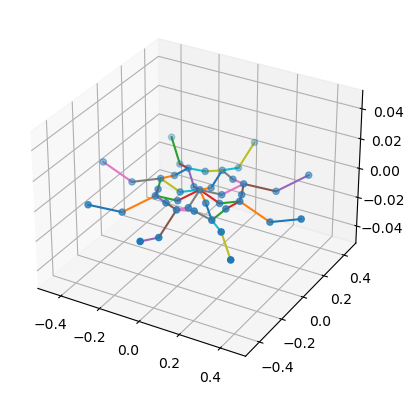

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone import Drone
from Scripts.beams import BeamType
import Scripts.FEA_3D as FEA_3D

def plot_drone_geometry(drone,q):
    ax = plt.figure().add_subplot(projection='3d')
    ax.set_xlim([-0.5, 0.5])
    ax.set_ylim([-0.5, 0.5])
    ax.set_zlim([-0.05, 0.05])
    drone_geo = drone.beam_system
    ax.scatter(drone_geo.nodes[:,0] + drone_geo.x_displacements,
               drone_geo.nodes[:,1] + drone_geo.y_displacements, 
               drone_geo.nodes[:,2] + drone_geo.z_displacements)
    
    for beam in drone_geo.beams:
        '''
        node_0_x = beam.start_node_coords[0]
        node_1_x = beam.end_node_coords[0]
        node_0_y = beam.start_node_coords[1]
        node_1_y = beam.end_node_coords[1]
        node_0_z = beam.start_node_coords[2]
        node_1_z = beam.end_node_coords[2]
        
        X_len = node_1_x - node_0_x
        Y_len = node_1_y - node_0_y
        Z_len = node_1_z - node_0_z

        X = np.empty(q)
        Y = np.empty(q)
        Z = np.empty(q)
        for i in range(q):
            N_X = FEA_3D.shape_function(X_len * i / q, X_len)
            N_Y = FEA_3D.shape_function(Y_len * i / q, Y_len)
            N_Z = FEA_3D.shape_function(Z_len * i / q, Z_len)
            X[i] = node_0_x + N_X[0] * beam.x_displacement[0] + N_X[1] * beam.x_angles[0] + N_X[2] * beam.x_displacement[1] + N_X[3] * beam.x_angles[1]
            Y[i] = node_0_y + N_Y[0] * beam.y_displacement[0] + N_Y[1] * beam.y_angles[0] +  N_Y[2] * beam.y_displacement[1] + N_Y[3] * beam.y_angles[1]
            Z[i] = node_0_z + N_Z[0] * beam.z_displacement[0] + N_Z[1] * beam.z_angles[0] + N_Z[2] * beam.z_displacement[1] + N_Z[3] * beam.z_angles[1]
        '''
        ax.plot([beam.start_node_coords[0] + beam.x_displacement[0], beam.end_node_coords[0] + beam.x_displacement[1]],
                [beam.start_node_coords[1] + beam.y_displacement[0], beam.end_node_coords[1] + beam.y_displacement[1]],
                [beam.start_node_coords[2] + beam.z_displacement[0], beam.end_node_coords[2] + beam.z_displacement[1]])


d1 = Drone("drone_test")
arm_beam = BeamType("annulus", [0.005, 0.0004], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [0.003, 0.00025], "Aluminum7075-T6", "strut_beam")

d1.create_drone_nodes(0.5,0.2,8)           # hub radius | nominal radius | number of blades
# d1.rotate_drone_nodes(0,math.pi/5,math.pi/60)      # x-axis | y-axis | z-axis
d1.create_drone_beams(arm_beam,strut_beam) # arm beam | strut beam

d1.boundary_conditions()
d1.solve_fea()

plot_drone_geometry(d1,10)